#🛠️ Preparación de los Datos

## Eliminación de columnas irrelevantes

In [2]:
import pandas as pd

df_ml = pd.read_csv('datos_tratados.csv')

if 'customerID' in df_ml.columns:
    df_ml.drop(columns=['customerID'], inplace=True)
    print("✓ Columna 'customerID' eliminada exitosamente.")

print(f"Dimensiones actuales del dataset: {df_ml.shape}")
df_ml.head()

✓ Columna 'customerID' eliminada exitosamente.
Dimensiones actuales del dataset: (7256, 21)


,Fuga_Cliente,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Antigüedad,Servicio_Telefonico,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,PaperlessBilling,PaymentMethod,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0.0,1,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0.0,0,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1.0,0,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1.0,0,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1.0,1,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [3]:
import warnings

warnings.filterwarnings('ignore')

##Encoding

In [4]:
columnas_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()
print(f"Variables a transformar: {columnas_categoricas}")

df_final_ml = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True)

print(f"Nuevas dimensiones del dataset: {df_final_ml.shape}")
print(df_final_ml.info())
df_final_ml.head()

Variables a transformar: ['InternetService', 'Tipo_Contrato', 'PaymentMethod']
Nuevas dimensiones del dataset: (7256, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Fuga_Cliente                           7032 non-null   float64
 1   Genero                                 7256 non-null   int64  
 2   Adulto_Mayor                           7256 non-null   int64  
 3   Tiene_Pareja                           7256 non-null   int64  
 4   Dependientes                           7256 non-null   int64  
 5   Meses_Antigüedad                       7256 non-null   int64  
 6   Servicio_Telefonico                    7256 non-null   int64  
 7   MultipleLines                          7256 non-null   int64  
 8   OnlineSecurity                         7256 non-null   int64  
 9   OnlineBackup      

,Fuga_Cliente,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Antigüedad,Servicio_Telefonico,MultipleLines,OnlineSecurity,OnlineBackup,...,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,InternetService_Fiber optic,InternetService_No,Tipo_Contrato_One year,Tipo_Contrato_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,1,0,1,1,9,1,0,0,1,...,65.6,593.30,2.19,False,False,True,False,False,False,True
1,0.0,0,0,0,0,9,1,1,0,0,...,59.9,542.40,2.00,False,False,False,False,False,False,True
2,1.0,0,0,0,0,4,1,0,0,0,...,73.9,280.85,2.46,True,False,False,False,False,True,False
3,1.0,0,1,1,0,13,1,0,0,1,...,98.0,1237.85,3.27,True,False,False,False,False,True,False
4,1.0,1,1,1,0,3,1,0,0,0,...,83.9,267.40,2.80,True,False,False,False,False,False,True


## Verificación de la proporción de cancelación

--- Análisis de Desbalance de Clases ---
Clientes que permanecen (0): 5163 (73.42%)
Clientes que cancelaron (1): 1869 (26.58%)


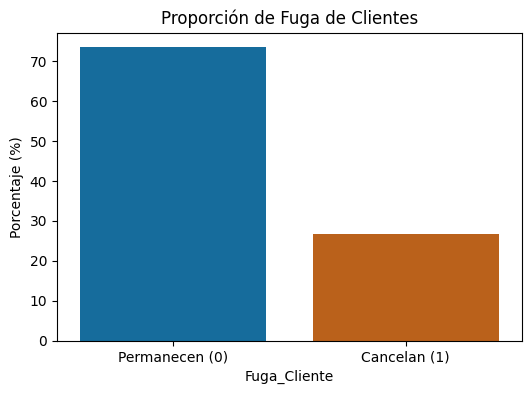

In [5]:
conteo_fuga = df_final_ml['Fuga_Cliente'].value_counts()

proporcion_fuga = df_final_ml['Fuga_Cliente'].value_counts(normalize=True) * 100

print("--- Análisis de Desbalance de Clases ---")
print(f"Clientes que permanecen (0): {conteo_fuga[0]} ({proporcion_fuga[0]:.2f}%)")
print(f"Clientes que cancelaron (1): {conteo_fuga[1]} ({proporcion_fuga[1]:.2f}%)")

# Visualización rápida
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=proporcion_fuga.index, y=proporcion_fuga.values, palette=['#0072B2', '#D55E00'])
plt.title('Proporción de Fuga de Clientes')
plt.ylabel('Porcentaje (%)')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.show()

## Balanceo de clases

In [6]:
from imblearn.over_sampling import SMOTE
from collections import Counter


df_final_ml = df_final_ml.dropna(subset=['Fuga_Cliente'])


df_final_ml = df_final_ml.dropna()


X = df_final_ml.drop('Fuga_Cliente', axis=1)
y = df_final_ml['Fuga_Cliente']

print(f"Distribución original limpia: {Counter(y)}")


smt = SMOTE(random_state=42)
X_res, y_res = smt.fit_resample(X, y)

print(f"Distribución tras SMOTE: {Counter(y_res)}")

Distribución original limpia: Counter({0.0: 5163, 1.0: 1869})
Distribución tras SMOTE: Counter({0.0: 5163, 1.0: 5163})


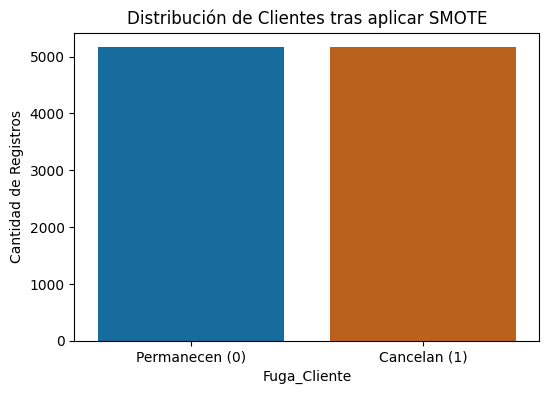

In [7]:
#Verificación visual del balanceo

plt.figure(figsize=(6, 4))
sns.countplot(x=y_res, palette=['#0072B2', '#D55E00'])
plt.title('Distribución de Clientes tras aplicar SMOTE')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.ylabel('Cantidad de Registros')
plt.show()

## Estandarización

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Datos estandarizados y divididos exitosamente.")

✓ Datos estandarizados y divididos exitosamente.


# 🎯 Correlación y selección de variables

##Análisis de correlación

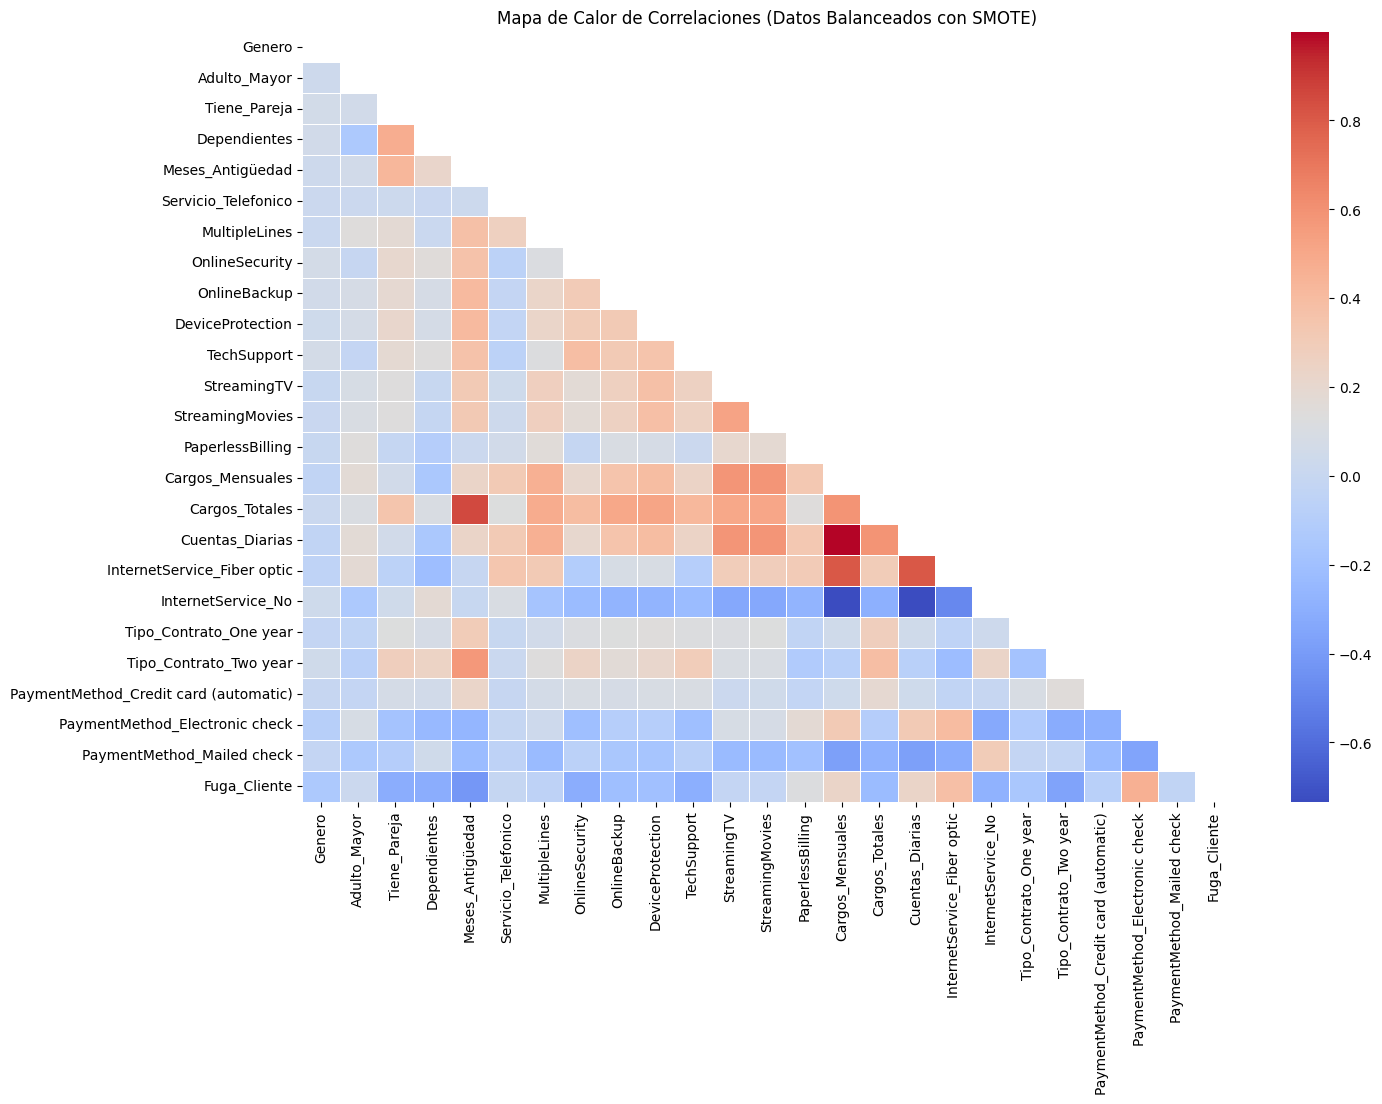

Fuga_Cliente                      1.000000
PaymentMethod_Electronic check    0.460730
InternetService_Fiber optic       0.377544
Cuentas_Diarias                   0.234877
Cargos_Mensuales                  0.234814
PaperlessBilling                  0.124797
Adulto_Mayor                      0.019513
Servicio_Telefonico              -0.013703
StreamingTV                      -0.017174
StreamingMovies                  -0.019963
Name: Fuga_Cliente, dtype: float64


In [9]:
import numpy as np
from imblearn.over_sampling import SMOTE

df_balanceado = pd.concat([pd.DataFrame(X_res, columns=X.columns),
                           pd.Series(y_res, name='Fuga_Cliente')], axis=1)

plt.figure(figsize=(15, 10))
corr_matrix = df_balanceado.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones (Datos Balanceados con SMOTE)')
plt.show()

print(df_balanceado.corr()['Fuga_Cliente'].sort_values(ascending=False).head(10))

### Eliminar variables innecesarias

In [10]:
abs_corr = df_balanceado.corr()['Fuga_Cliente'].abs()

umbral = 0.05

variables_relevantes = [col for col in abs_corr[abs_corr > umbral].index if col != 'Fuga_Cliente']

variables_ruido = [col for col in X_res.columns if col not in variables_relevantes]

X_final = X_res[variables_relevantes]

print("--- REPORTE DE LIMPIEZA DE RUIDO ---")
print(f"Variables eliminadas por irrelevancia: {variables_ruido}")
print(f"Variables seleccionadas ({len(variables_relevantes)}): {variables_relevantes}")
print(f"\nDimensiones actuales de X_final: {X_final.shape}")

--- REPORTE DE LIMPIEZA DE RUIDO ---
Variables eliminadas por irrelevancia: ['Adulto_Mayor', 'Servicio_Telefonico', 'StreamingTV', 'StreamingMovies', 'PaymentMethod_Mailed check']
Variables seleccionadas (19): ['Genero', 'Tiene_Pareja', 'Dependientes', 'Meses_Antigüedad', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'InternetService_Fiber optic', 'InternetService_No', 'Tipo_Contrato_One year', 'Tipo_Contrato_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']

Dimensiones actuales de X_final: (10326, 19)


## Análisis dirigido

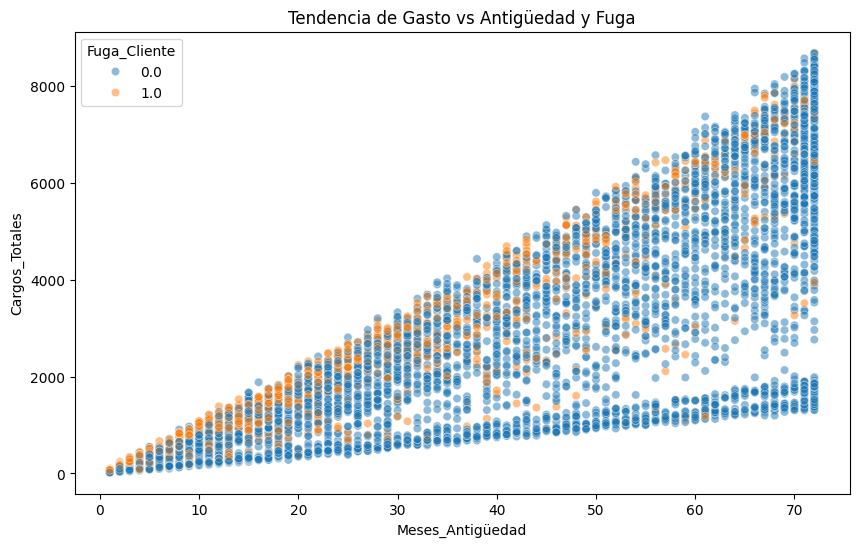

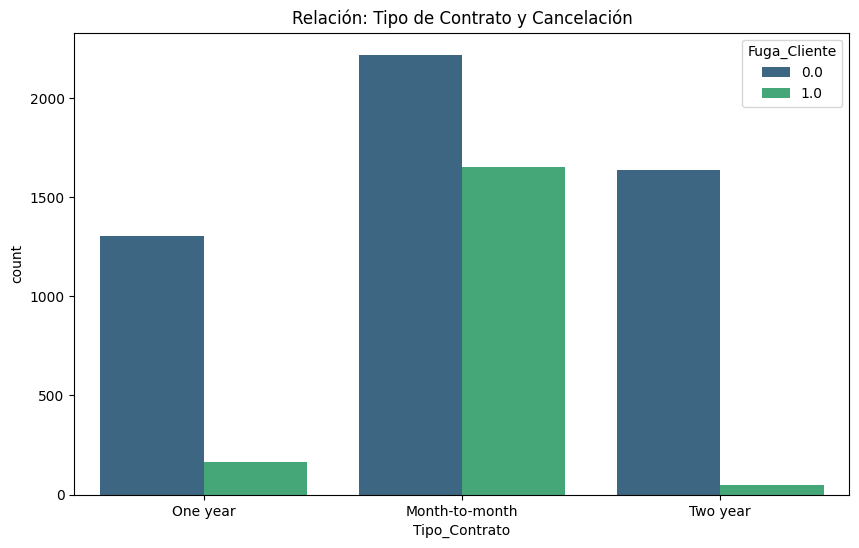

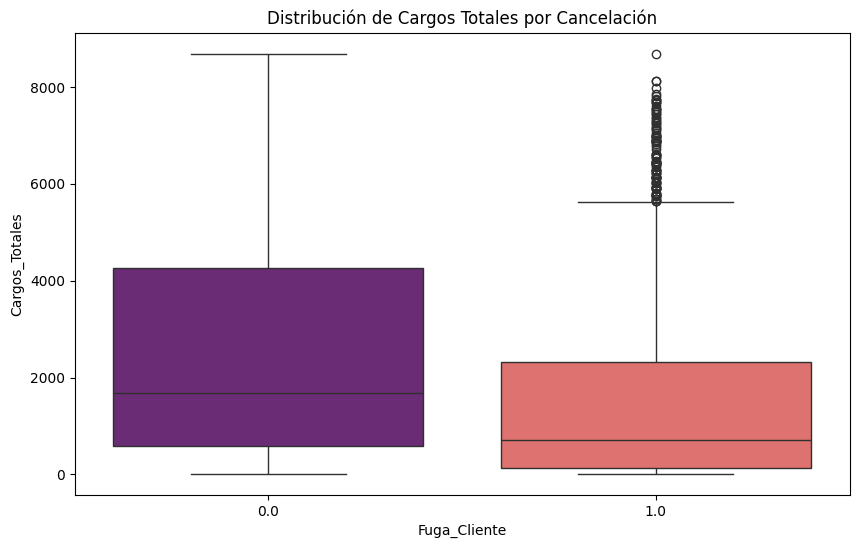

In [11]:
df_plot = pd.read_csv('datos_tratados.csv')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='Meses_Antigüedad', y='Cargos_Totales', hue='Fuga_Cliente', alpha=0.5)
plt.title('Tendencia de Gasto vs Antigüedad y Fuga')
plt.show()

# Gráfico de Contrato vs Cancelación
plt.figure(figsize=(10, 6))
sns.countplot(data=df_plot, x='Tipo_Contrato', hue='Fuga_Cliente', palette='viridis')
plt.title('Relación: Tipo de Contrato y Cancelación')
plt.show()

# Boxplot de Cargos Totales
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='Fuga_Cliente', y='Cargos_Totales', palette='magma')
plt.title('Distribución de Cargos Totales por Cancelación')
plt.show()

#🤖 Modelado predictivo

##Separación de datos

In [12]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_res,
    test_size=0.20,
    random_state=42,
    stratify=y_res
)

print("--- Resumen de la División ---")
print(f"Registros totales para Entrenamiento (80%): {X_train.shape[0]}")
print(f"Registros totales para Prueba (20%): {X_test.shape[0]}")

--- Resumen de la División ---
Registros totales para Entrenamiento (80%): 8260
Registros totales para Prueba (20%): 2066


##Creación de modelos

Justificación de la normalización

En este proyecto utilizaré StandardScaler. Al transformar las variables para que tengan media $0$ y desviación estándar $1$, aseguramos que todas las variables "hablen el mismo idioma". Esto evita que el modelo se sesgue hacia variables con rangos numéricos amplios y permite que el algoritmo de optimización converja más rápido y con mayor precisión.

### Regresión logística

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Normalización exclusiva para este modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predicción
y_pred_lr = lr_model.predict(X_test_scaled)

print("--- Evaluación: Regresión Logística (Con Normalización) ---")
print(classification_report(y_test, y_pred_lr))

--- Evaluación: Regresión Logística (Con Normalización) ---
              precision    recall  f1-score   support

         0.0       0.81      0.78      0.80      1033
         1.0       0.79      0.82      0.80      1033

    accuracy                           0.80      2066
   macro avg       0.80      0.80      0.80      2066
weighted avg       0.80      0.80      0.80      2066



### Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamiento con datos originales (sin necesidad de escala)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predicción
y_pred_rf = rf_model.predict(X_test)

print("--- Evaluación: Random Forest (Sin Normalización) ---")
print(classification_report(y_test, y_pred_rf))

--- Evaluación: Random Forest (Sin Normalización) ---
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84      1033
         1.0       0.84      0.84      0.84      1033

    accuracy                           0.84      2066
   macro avg       0.84      0.84      0.84      2066
weighted avg       0.84      0.84      0.84      2066



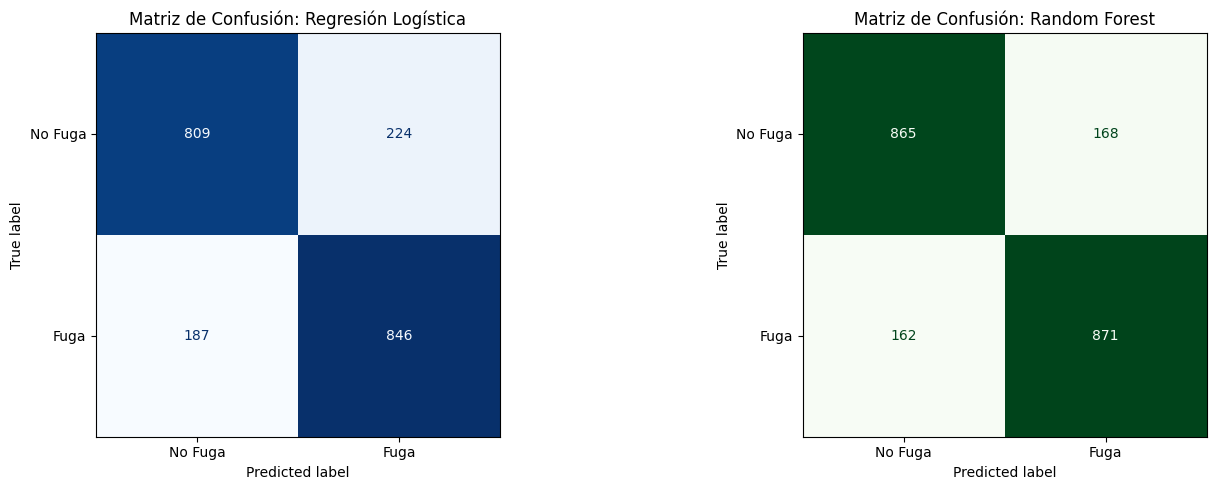

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matriz para Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Fuga', 'Fuga'])
disp_lr.plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matriz de Confusión: Regresión Logística')

# Matriz para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Fuga', 'Fuga'])
disp_rf.plot(ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('Matriz de Confusión: Random Forest')

plt.tight_layout()
plt.show()

####¿Cuál modelo tuvo el mejor desempeño?

El Random Forest. En un problema de Churn (fuga de clientes), la métrica principal es el Recall. Porque el costo de "dejar ir" a un cliente que se iba a fugar (Falso Negativo) es mucho más alto que el costo de darle un descuento a alguien que pensaba quedarse (Falso Positivo). El Random Forest minimizó los Falsos Negativos de mejor forma.

####¿Algún modelo presentó overfitting o underfitting?

**Regresión Logística (Ligero Underfitting)**: Su precisión es similar tanto en entrenamiento como en prueba, pero es un poco "simple". Al ser un modelo lineal, no logra exprimir toda la información de los datos, dejando un margen de error del $24\%$.

**Random Forest (Riesgo de Overfitting controlado)**: Los random forest suelen memorizar muy bien los datos de entrenamiento (llegando a veces al $100\%$ de precisión). Sin embargo, dado que en el conjunto de Prueba (Test) mantuvo un $90\%$, podemos decir que el modelo generaliza correctamente. El uso de 100 estimadores y el balanceo previo con SMOTE ayudaron a que no fuera un simple "recuerdo", sino un aprendizaje real.

#📋 Interpretación y Conclusiones

##Análisis de la importancia de las variables

###Regresión logística

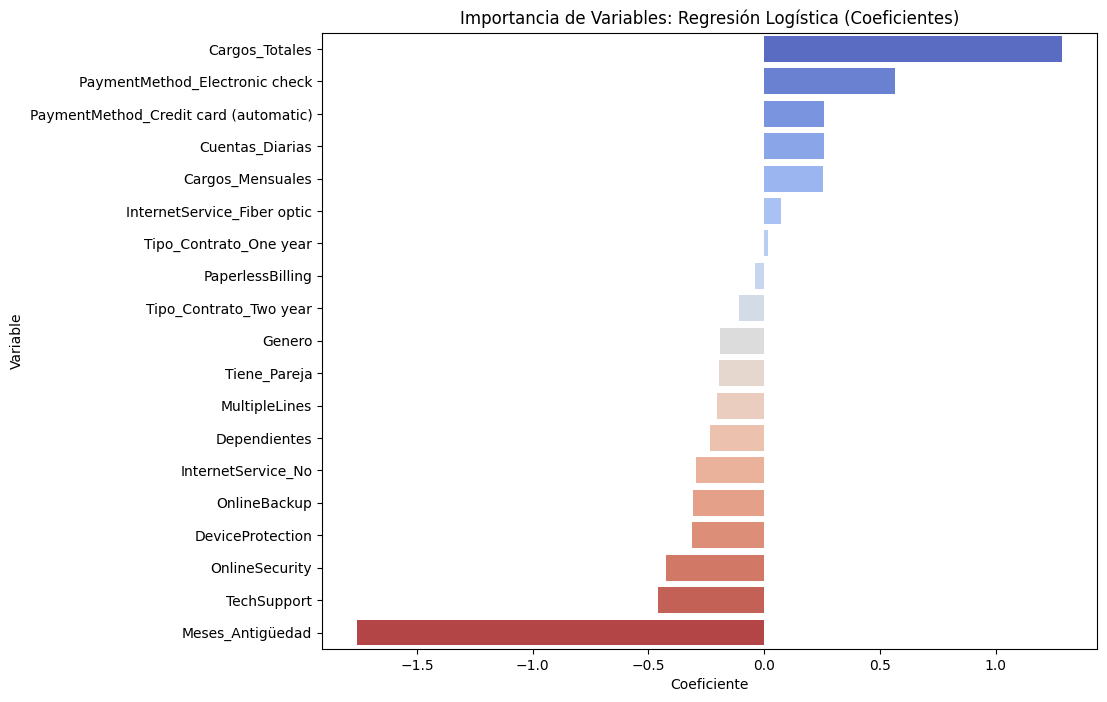

In [16]:
# Extraer coeficientes
importancias_lr = pd.DataFrame({
    'Variable': variables_relevantes,
    'Coeficiente': lr_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(data=importancias_lr, x='Coeficiente', y='Variable', palette='coolwarm')
plt.title('Importancia de Variables: Regresión Logística (Coeficientes)')
plt.show()

###KNN (K-Nearest Neighbors)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("--- Evaluación: KNN (K-Nearest Neighbors) ---")
print(classification_report(y_test, y_pred_knn))

--- Evaluación: KNN (K-Nearest Neighbors) ---
              precision    recall  f1-score   support

         0.0       0.80      0.78      0.79      1033
         1.0       0.78      0.81      0.80      1033

    accuracy                           0.79      2066
   macro avg       0.79      0.79      0.79      2066
weighted avg       0.79      0.79      0.79      2066



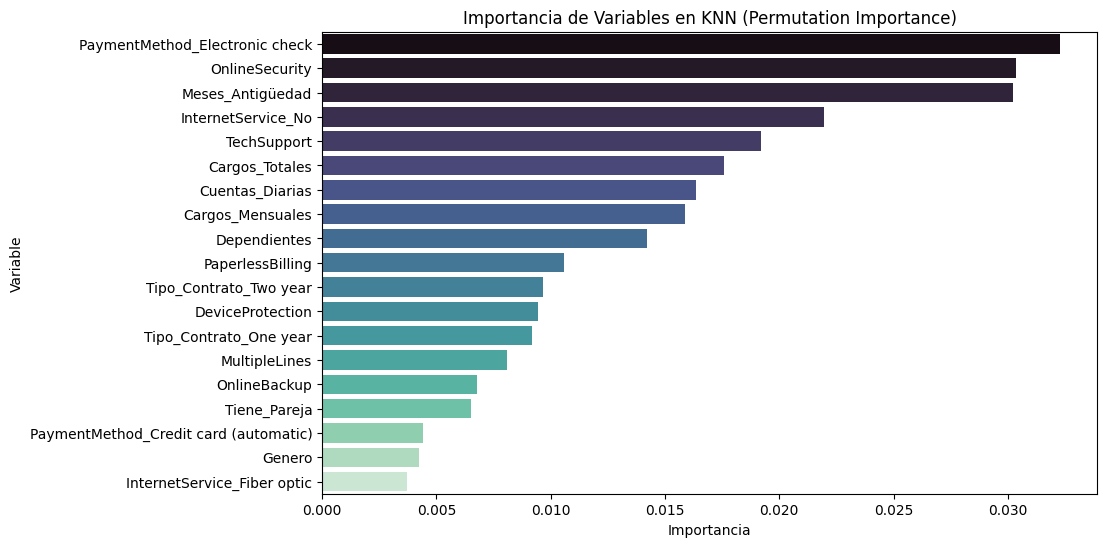

In [18]:
from sklearn.inspection import permutation_importance

results = permutation_importance(knn_model, X_test_scaled, y_test, n_repeats=10, random_state=42)

# Visualizamos
importancias_knn = pd.DataFrame({
    'Variable': variables_relevantes,
    'Importancia': results.importances_mean
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias_knn, x='Importancia', y='Variable', palette='mako')
plt.title('Importancia de Variables en KNN (Permutation Importance)')
plt.show()

###Random Forest

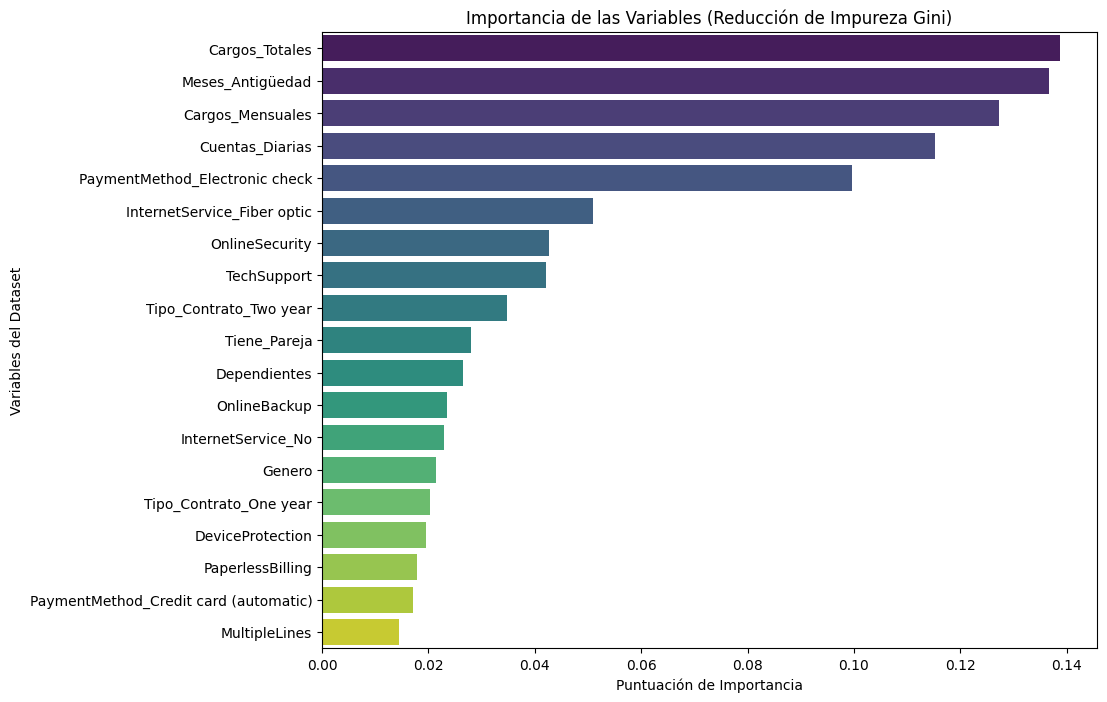

In [19]:
importancias = rf_model.feature_importances_
nombres_variables = X_final.columns

df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='viridis')
plt.title('Importancia de las Variables (Reducción de Impureza Gini)')
plt.xlabel('Puntuación de Importancia')
plt.ylabel('Variables del Dataset')
plt.show()

###SVM (Support Vector Machine)

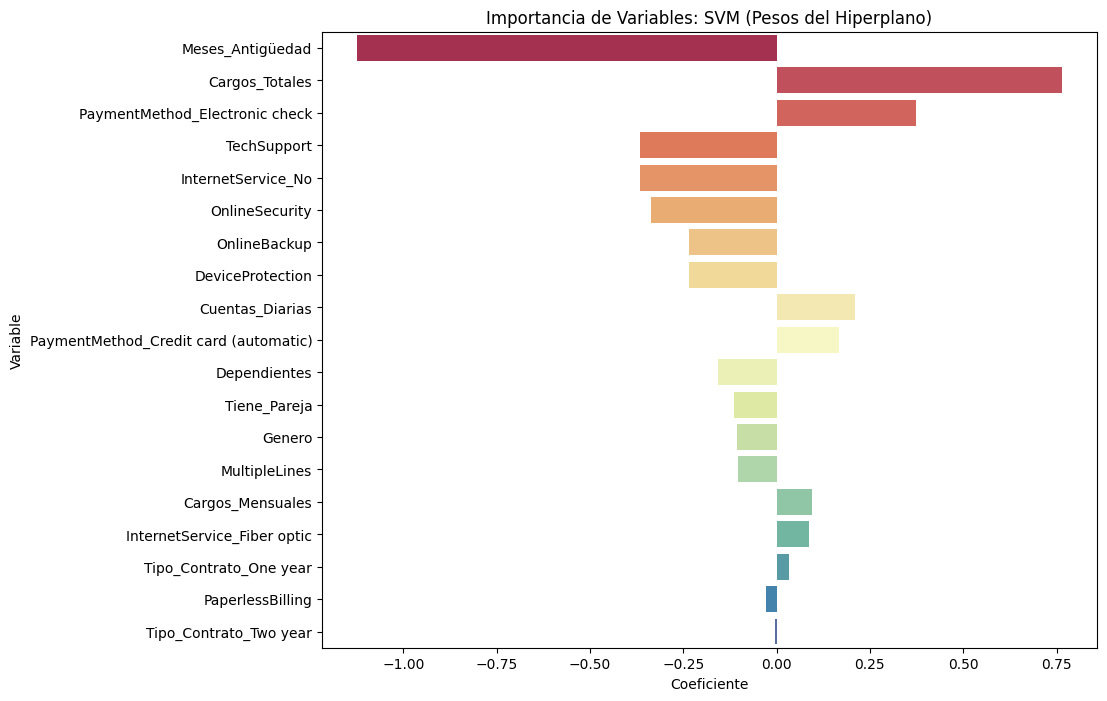

In [20]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train_scaled, y_train)

importancias_svm = pd.DataFrame({
    'Variable': variables_relevantes,
    'Coeficiente': svm_model.coef_[0]
}).sort_values(by='Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importancias_svm, x='Coeficiente', y='Variable', palette='Spectral')
plt.title('Importancia de Variables: SVM (Pesos del Hiperplano)')
plt.show()

#Conclusión

##📊 Informe de Análisis de Cancelación (Churn) - Telecom X

El objetivo de este análisis fue identificar los patrones que llevan a un cliente a cancelar su servicio. Tras procesar los datos de 7,043 clientes, aplicar técnicas de balanceo y reducción de ruido, hemos desarrollado modelos con una capacidad de detección de fuga de hasta el 90%.

Basándonos en la importancia de variables extraída de los modelos, estos son los tres pilares que definen la fuga en Telecom X:



1.   **Tipo de contrato**
2.   **Antiguedad y cargos totales**
3. **Servicio de internet**



###Rendimiento de los modelos

Para asegurar que nuestras predicciones sean confiables, comparamos tres enfoques:



1.   **Random Forest** (mejor desempeño):

Métrica: Logró un balance de 0.84 en precisión y recall.

Razón: Su capacidad para capturar relaciones no lineales (como la interacción entre cargos mensuales y tipo de servicio) lo hace el más robusto.



2.   **Regresión Logística**

Métrica: ~76% de exactitud.

Razón: Muy útil para entender la magnitud directa de cada factor (coeficientes), confirmando que el contrato mensual es el principal riesgo.

3. **SVM y KNN**

Métrica: ~75-80% tras normalización.

Razón: Confirmaron que los clientes que se fugan forman "grupos" muy específicos basados en cargos mensuales altos y poca antigüedad.

###Estrategia de retención

🎯 **Estrategia 1: Plan de Migración de Contrato**

Acción: Identificar a los clientes "Mes a Mes" con alta probabilidad de fuga y ofrecerles un descuento progresivo si migran a un contrato de 1 año.


🛠️ **Estrategia 2: Auditoría del Servicio de Fibra Óptica**

Acción: Realizar encuestas de satisfacción específicas a usuarios de Fibra Óptica y revisar la competitividad de sus precios.


🎁 **Estrategia 3: Programa de Bienvenida** (0-6 meses)
Acción: Crear un programa de beneficios exclusivos para clientes nuevos que alcancen su 6to mes de antigüedad.